In [1]:
# setup
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from k_means_constrained import KMeansConstrained
import re



In [2]:
# load data
batDict = pickle.load(open('../data/batDict.pkl', 'rb'))
cellIds = list(batDict.keys())

In [3]:
# Pick a sample cell to inspect
sample_cell_id = list(batDict.keys())[0]
cell = batDict[sample_cell_id]

print("=" * 60)
print("CELL-LEVEL KEYS")
print("=" * 60)
for key in cell.keys():
    val = cell[key]
    print(f"\n  Key: '{key}'")
    print(f"    Type: {type(val)}")
    if isinstance(val, np.ndarray):
        print(f"    Shape: {val.shape}")
        print(f"    dtype: {val.dtype}")
        print(f"    Sample values (first 5): {val[:5]}")
        print(f"    Min: {np.nanmin(val):.4f}  |  Max: {np.nanmax(val):.4f}  |  Mean: {np.nanmean(val):.4f}")
    elif isinstance(val, dict):
        print(f"    (Nested dict — see below)")
    else:
        print(f"    Value: {val}")

# -------------------------------------------------------
print("\n" + "=" * 60)
print("CELL SUMMARY KEYS")
print("=" * 60)
summary = cell['summary']
for key in summary.keys():
    arr = summary[key]
    print(f"\n  Key: '{key}'")
    print(f"    Type: {type(arr)}")
    if isinstance(arr, np.ndarray):
        print(f"    Shape: {arr.shape}  (one value per cycle)")
        print(f"    dtype: {arr.dtype}")
        print(f"    Sample values (first 5): {arr[:5]}")
        print(f"    Min: {np.nanmin(arr):.4f}  |  Max: {np.nanmax(arr):.4f}  |  Mean: {np.nanmean(arr):.4f}")
    else:
        print(f"    Value: {arr}")

# -------------------------------------------------------
print("\n" + "=" * 60)
print("CELL CYCLE DICTIONARY KEYS  (showing cycle 1)")
print("=" * 60)
cycle_keys = list(cell['cycles'].keys())
sample_cycle = cell['cycles'][cycle_keys[0]]
for key in sample_cycle.keys():
    arr = sample_cycle[key]
    print(f"\n  Key: '{key}'")
    print(f"    Type: {type(arr)}")
    if isinstance(arr, np.ndarray):
        print(f"    Shape: {arr.shape}  (size varies by cycle)")
        print(f"    dtype: {arr.dtype}")
        print(f"    Sample values (first 5): {arr[:5]}")
        print(f"    Min: {np.nanmin(arr):.4f}  |  Max: {np.nanmax(arr):.4f}  |  Mean: {np.nanmean(arr):.4f}")
    else:
        print(f"    Value: {arr}")

CELL-LEVEL KEYS

  Key: 'cycle_life'
    Type: <class 'float'>
    Value: 1852.0

  Key: 'charge_policy'
    Type: <class 'str'>
    Value: 3.6C(80%)-3.6C

  Key: 'summary'
    Type: <class 'dict'>
    (Nested dict — see below)

  Key: 'cycles'
    Type: <class 'dict'>
    (Nested dict — see below)

CELL SUMMARY KEYS

  Key: 'IR'
    Type: <class 'numpy.ndarray'>
    Shape: (1851,)  (one value per cycle)
    dtype: float64
    Sample values (first 5): [0.         0.01674235 0.01672431 0.01668125 0.01666187]
    Min: 0.0000  |  Max: 0.0190  |  Mean: 0.0170

  Key: 'QC'
    Type: <class 'numpy.ndarray'>
    Shape: (1851,)  (one value per cycle)
    dtype: float64
    Sample values (first 5): [0.        1.0710422 1.0716741 1.0723044 1.07297  ]
    Min: 0.0000  |  Max: 1.5468  |  Mean: 1.0209

  Key: 'QD'
    Type: <class 'numpy.ndarray'>
    Shape: (1851,)  (one value per cycle)
    dtype: float64
    Sample values (first 5): [0.        1.0706892 1.0719005 1.0725095 1.073174 ]
    Min: 0.

In [4]:
# code for data dictionary
summary_keys = ['IR', 'QC', 'QD', 'Tavg', 'Tmin', 'Tmax', 'chargetime', 'cycle']

accumulators = {k: [] for k in summary_keys}

for cell_id, cell in batDict.items():
    for k in summary_keys:
        arr = cell['summary'].get(k, None)
        if arr is not None:
            accumulators[k].append(arr)

for k in summary_keys:
    combined = np.concatenate(accumulators[k])
    print(f"\n  '{k}'")
    print(f"    Min: {np.nanmin(combined):.4f}  |  Max: {np.nanmax(combined):.4f}  |  Mean: {np.nanmean(combined):.4f}")

# -------------------------------------------------------
print("\n" + "=" * 60)
print("CYCLE DICT KEY RANGES — across all cells, all cycles")
print("=" * 60)

cycle_keys = ['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'dQdV', 't']

accumulators2 = {k: [] for k in cycle_keys}

for cell_id, cell in batDict.items():
    for cycle_num, cycle_data in cell['cycles'].items():
        for k in cycle_keys:
            arr = cycle_data.get(k, None)
            if arr is not None:
                accumulators2[k].append(arr)

for k in cycle_keys:
    combined = np.concatenate(accumulators2[k])
    print(f"\n  '{k}'")
    print(f"    Min: {np.nanmin(combined):.4f}  |  Max: {np.nanmax(combined):.4f}  |  Mean: {np.nanmean(combined):.4f}")


  'IR'
    Min: 0.0000  |  Max: 0.0244  |  Mean: 0.0119

  'QC'
    Min: 0.0000  |  Max: 2.9659  |  Mean: 1.0191

  'QD'
    Min: 0.0000  |  Max: 2.8841  |  Mean: 1.0188

  'Tavg'
    Min: 0.0000  |  Max: 41.5460  |  Mean: 34.0459

  'Tmin'
    Min: 0.0000  |  Max: 37.1642  |  Mean: 31.3711

  'Tmax'
    Min: 0.0000  |  Max: 44.7095  |  Mean: 37.3727

  'chargetime'
    Min: 0.0000  |  Max: 1290.3708  |  Mean: 11.2356

  'cycle'
    Min: 1.0000  |  Max: 2236.0000  |  Mean: 481.3953

CYCLE DICT KEY RANGES — across all cells, all cycles

  'I'
    Min: -12.2134  |  Max: 8.4381  |  Mean: 0.2545

  'Qc'
    Min: 0.0000  |  Max: 2.9659  |  Mean: 0.7994

  'Qd'
    Min: 0.0000  |  Max: 2.8841  |  Mean: 0.2726

  'Qdlin'
    Min: -1272.5843  |  Max: 1430.6886  |  Mean: 0.6724

  'T'
    Min: 0.0000  |  Max: 44.7095  |  Mean: 33.8879

  'Tdlin'
    Min: -394.4418  |  Max: 2089.2051  |  Mean: 34.4450

  'V'
    Min: 0.0000  |  Max: 6.6061  |  Mean: 3.1195

  'dQdV'
    Min: -47.3287  |  Max: 0

In [9]:

"""
Compute SOC-weighted average charging C-rate (g) from a charge_policy string.

FORMAT B — annotated; 3-step protocol:
    "3.6C(80%)-3.6C", "4C(31%)-5", "3.7C(31%)-5.9C-newstructure"
    g = CC1*bp + CC2*(0.80-bp) + 1.0*0.20

FORMAT C — pure numerics; 5-step protocol:
    "3.6-6-5.6-4.755", "8-6-4.8-3"
    g = (CC1+CC2+CC3+CC4)*0.20 + 1.0*0.20

"in both cases the final step is a 1C constant current charge from 80–100% SOC" - Zhou et Al
"""


def parseProtocol(policy):
    policy = policy.replace('-newstructure', '').strip()

    if not re.search(r'[C%]', policy, re.IGNORECASE):
        rates = [float(x) for x in policy.split('-') if x.strip()]
        return ('C', rates)  # Format C

    m = re.match(r'([\d.]+)[Cc]\(([\d.]+)%\)-([\d.]+)[Cc]?', policy)
    if m:
        return ('B', [float(m.group(1)), float(m.group(2)) / 100, float(m.group(3))])

    raise ValueError(f"Cannot parse protocol: '{policy}'")


def parse_avg_crate(charge_policy):
    fmt, vals = parseProtocol(charge_policy)
    if fmt == 'C':
        return sum(vals) * 0.20 + 1.0 * 0.20
    cc1, bp, cc2 = vals
    return cc1 * bp + cc2 * (0.80 - bp) + 1.0 * 0.20


def protocolFeatures(policy):
    fmt, vals = parseProtocol(policy)
    if fmt == 'C':
        return np.array([vals[0], vals[1], vals[2], vals[3]])  # 4 rates + fixed BP
    else:
        cc1, bp, cc2 = vals
        return np.array([cc1, bp, cc2, 0.0])  # pad with zeros


In [10]:
avgCrates  = np.array([parse_avg_crate(batDict[c]['charge_policy']) for c in cellIds])
eol_cycles = np.array([batDict[c]['cycle_life'] for c in cellIds])

print(f"Dataset: {len(cellIds)} cells "
      f"({sum(1 for c in cellIds if not c.startswith('b4'))} Severson + "
      f"{sum(1 for c in cellIds if c.startswith('b4'))} Attia)")
print(f"EoL range: {eol_cycles.min():.0f}–{eol_cycles.max():.0f} cycles "
      f"(mean={eol_cycles.mean():.0f}, paper: 797)")
print(f"Avg C-rate range: {avgCrates.min():.3f}–{avgCrates.max():.3f}C")

Dataset: 169 cells (124 Severson + 45 Attia)
EoL range: 148–2237 cycles (mean=794, paper: 797)
Avg C-rate range: 3.080–4.800C


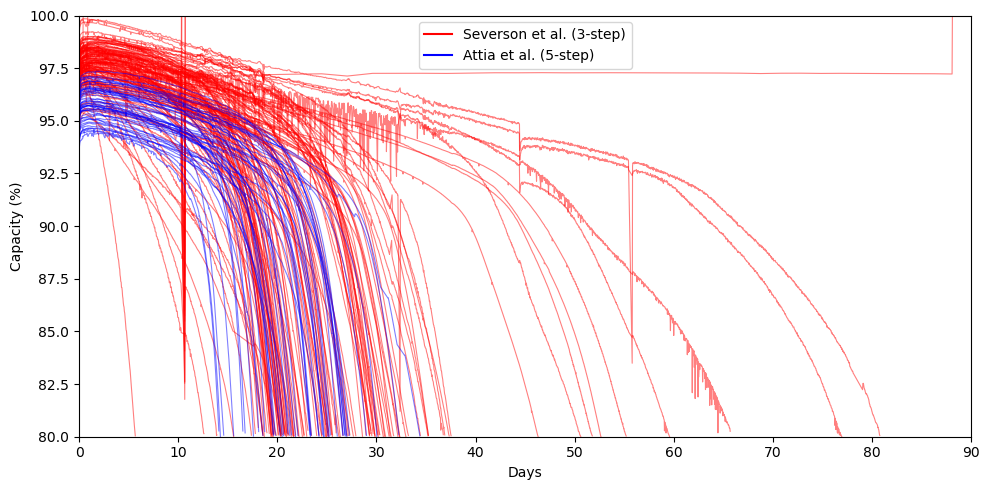

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

NOMINAL_CAP = 1.1  # Ah

for key in batDict:
    cell    = batDict[key]
    qd      = cell['summary']['QD']
    
    # compute actual cycle durations from raw cycle data
    cycle_durations = []
    for ck in cell['cycles']:
        t = cell['cycles'][ck]['t']
        cycle_durations.append(t[-1] - t[0])
    
    days    = np.cumsum(cycle_durations) / 60 / 24   
    cap_pct = qd / NOMINAL_CAP * 100
    mask    = (cap_pct >= 80) & (len(days) == len(qd))  # safety check
    
    # trim to same length in case cycles and summary differ by 1
    n       = min(len(days), len(qd))
    days    = days[:n]
    cap_pct = cap_pct[:n]
    mask    = cap_pct >= 80
    
    color   = 'blue' if key.startswith('b4') else 'red'
    ax.plot(days[mask], cap_pct[mask], color=color, alpha=0.5, linewidth=0.8)

ax.set_xlabel('Days')
ax.set_ylabel('Capacity (%)')
ax.set_xlim(0, 90)
ax.set_ylim(80, 100)

ax.legend(handles=[
    Line2D([0], [0], color='red',  label='Severson et al. (3-step)'),
    Line2D([0], [0], color='blue', label='Attia et al. (5-step)')
])
plt.tight_layout()
plt.show()

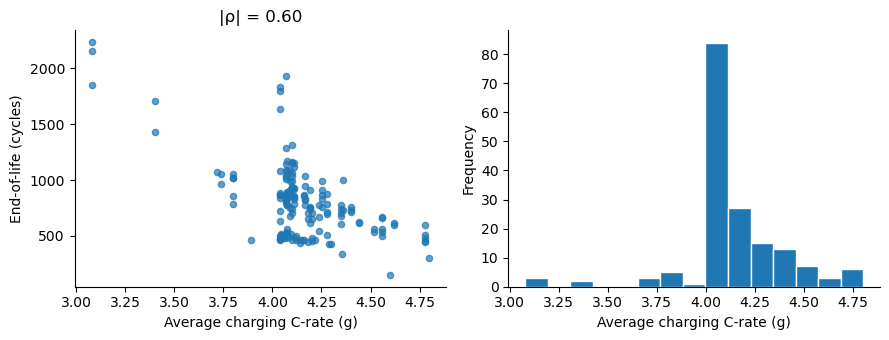

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

axes[0].scatter(avgCrates, eol_cycles, s=20, alpha=0.7, color='#1f77b4')
axes[0].set_xlabel('Average charging C-rate (g)')
axes[0].set_ylabel('End-of-life (cycles)')
corr = np.corrcoef(avgCrates, eol_cycles)[0,1]
axes[0].set_title(f'|ρ| = {abs(corr):.2f}')

axes[1].hist(avgCrates, bins=15, color='#1f77b4', edgecolor='white')
axes[1].set_xlabel('Average charging C-rate (g)')
axes[1].set_ylabel('Frequency')

for ax in axes:
    for s in ['top','right']:
        ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig('avgCrate_eol.png', dpi=150)
plt.show()


In [13]:

# setup for grouping algorithms
n  = len(cellIds)

policy_list      = sorted(set(batDict[c]['charge_policy'] for c in cellIds))
policy_to_idx    = {p: i for i, p in enumerate(policy_list)}
cellPolicyId     = np.array([policy_to_idx[batDict[c]['charge_policy']]
                              for c in cellIds])
policy_avgCrate  = np.array([avgCrates[cellPolicyId == p].mean()
                              for p in range(len(policy_list))])
policy_cellcount = np.array([(cellPolicyId == p).sum()
                              for p in range(len(policy_list))])
policy_features  = np.array([protocolFeatures(p) for p in policy_list])
policy_mean_eol  = np.array([eol_cycles[cellPolicyId == p].mean()
                              for p in range(len(policy_list))])

# partition data into N_GROUPS groups
N_GROUPS = 8

# count number of policies for each grouping, cells with the same policy will belong to the same group
def groupCellCounts(polGrp):
    counts = np.zeros(N_GROUPS, dtype=int) # initialize array that will store group-level cell count values
    for p in range(len(policy_list)):
        counts[polGrp[p]] += policy_cellcount[p] # increment counts by # of cells with a specific policy, polGrp maps policy index to group index
    return counts

# compute ratio of variance between groups over total variance (var between groups + var of total population)
def computeVPC(groupIds, eol):
    nj      = np.array([(groupIds == g).sum() for g in range(N_GROUPS)]) # array containing number of cells in jth group
    u_bar   = eol.mean() # population avg EoL
    u_bar_j = np.array([eol[groupIds == g].mean() for g in range(N_GROUPS)]) # array containing mean EoL for each group
    s2_grp  = np.sum(nj * (u_bar_j - u_bar)**2) / len(eol) # between group variance (weighted variance of group means and population mean)
    s2_ind  = np.sum([np.sum((eol[groupIds == g] - u_bar_j[g])**2) # sum of within group variances
                      for g in range(N_GROUPS)]) / len(eol)
    return s2_grp / (s2_ind + s2_grp) # # VPC = between / (within + between)



In [15]:
#  hill climbing with random restarts
np.random.seed(42)
MIN_SIZE    = 10
target      = 0.745
N_RESTARTS  = 20
best_overall_vpc = 0
best_overall_grp = None

# randomly assign policies to groups, ensuring each group has at least MIN_SIZE cells
def randomValidStart():
    for _ in range(100_000): # iterate over random assignments up to 100000 times
        polGrp = np.random.randint(0, N_GROUPS, size=len(policy_list)) # randomly assign each policy to a group
        if groupCellCounts(polGrp).min() >= MIN_SIZE: # ensure each group has at least MIN_SIZE cells
            return polGrp
    return None

for restart in range(N_RESTARTS):
    # start with valid random policy group assignment
    current_polGrp  = randomValidStart()
    if current_polGrp is None:
        continue
    current_cellGrp = np.array([current_polGrp[cellPolicyId[i]] for i in range(n)]) # map cells to group number based on their policy
    current_vpc     = computeVPC(current_cellGrp, eol_cycles)

    for _ in range(200_000):
        p1, p2 = np.random.choice(len(policy_list), size=2, replace=False) # pick two random policies
        if current_polGrp[p1] == current_polGrp[p2]: # try again if these policies belong to same group
            continue
        candidate = current_polGrp.copy()
        candidate[p1], candidate[p2] = candidate[p2], candidate[p1] # for these two policies, swap their groups
        if groupCellCounts(candidate).min() < MIN_SIZE: # if swap violates MIN_SIZE requirement, try again
            continue
        candidate_cellGrp = np.array([candidate[cellPolicyId[i]] for i in range(n)]) # array of cells and their respective groups
        candidate_vpc     = computeVPC(candidate_cellGrp, eol_cycles)
        if abs(candidate_vpc - target) < abs(current_vpc - target): # if we get closer to target vpc, update the policy group array
            current_polGrp  = candidate
            current_vpc     = candidate_vpc
        if abs(current_vpc - target) < 0.001: # stop when algorithm converges
            break
    
    # track status of best vpc and grouping after 200K iterations
    print(f"Restart {restart:>2}: VPC={current_vpc*100:.3f}%")
    if current_vpc > best_overall_vpc:
        best_overall_vpc = current_vpc
        best_overall_grp = current_polGrp.copy()
    if abs(best_overall_vpc - target) < 0.001:
        print(f"  Converged at restart {restart}!")
        break



Restart  0: VPC=72.028%
Restart  1: VPC=70.031%
Restart  2: VPC=72.326%
Restart  3: VPC=68.547%
Restart  4: VPC=66.593%
Restart  5: VPC=74.406%
  Converged at restart 5!


VPC = 74.406%

Group  cells  policies    avgC  meanEoL    std
-----------------------------------------------------------------
    0      13          9    4.179       500      37
    1      45         15    4.150       832     108
    2      12          5    3.612      1565     431
    3      10         10    4.066       481       9
    4      40          9    3.989       994     207
    5      25         11    4.261       627      81
    6      10          5    4.160       556     115
    7      14         14    4.250       411      88


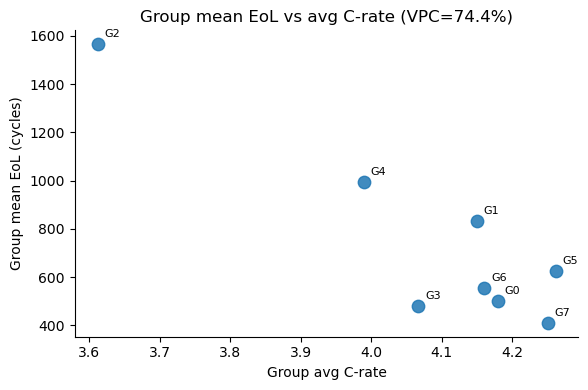


Pearson correlation with mean policy EoL:
  avg C-rate: -0.610


In [20]:
# hill climb results

# Load and explore (run this cell independently next time)
final_cellGrp = np.array([best_overall_grp[cellPolicyId[i]] for i in range(n)])
final_vpc     = computeVPC(final_cellGrp, eol_cycles)

nj      = np.array([(final_cellGrp == g).sum() for g in range(N_GROUPS)])
u_bar_j = np.array([eol_cycles[final_cellGrp == g].mean() for g in range(N_GROUPS)])

print(f"VPC = {final_vpc*100:.3f}%\n")

# Group summary table
print(f"{'Group':>5} {'cells':>6} {'policies':>9} {'avgC':>7} {'meanEoL':>8} {'std':>6}")
print("-" * 65)
for g in range(N_GROUPS):
    cmask = final_cellGrp == g
    pmask = best_overall_grp == g
    print(f"  {g:>3}  {nj[g]:>6}  {pmask.sum():>9}  "
          f"{policy_avgCrate[pmask].mean():>7.3f}  "
          f"{u_bar_j[g]:>8.0f}  {eol_cycles[cmask].std():>6.0f}")

# Scatter
g_avgCrate = np.array([policy_avgCrate[best_overall_grp == g].mean() for g in range(N_GROUPS)])
g_meanEoL  = u_bar_j  # already computed

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(g_avgCrate, g_meanEoL, s=80, alpha=0.85)
for g in range(N_GROUPS):
    ax.annotate(f'G{g}', (g_avgCrate[g], g_meanEoL[g]), textcoords='offset points', xytext=(5, 5), fontsize=8)
ax.set_xlabel('Group avg C-rate')
ax.set_ylabel('Group mean EoL (cycles)')
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
plt.title(f'Group mean EoL vs avg C-rate (VPC={final_vpc*100:.1f}%)')
plt.tight_layout()
plt.show()

# Correlation
print("\nPearson correlation with mean policy EoL:")
r = np.corrcoef(policy_avgCrate, policy_mean_eol)[0,1]
print(f"  avg C-rate: {r:+.3f}")

In [ ]:
print(f"Total unique policies: {len(policy_list)}")
for i, p in enumerate(policy_list):
    print(f"  [{i:>2}] {p}")

Total unique policies: 78
  [ 0] 1C(4%)-6C
  [ 1] 2C(10%)-6C
  [ 2] 2C(2%)-5C
  [ 3] 2C(7%)-5.5C
  [ 4] 3.6-6-5.6-4.755
  [ 5] 3.6C(2%)-4.85C
  [ 6] 3.6C(22%)-5.5C
  [ 7] 3.6C(30%)-6C
  [ 8] 3.6C(80%)-3.6C
  [ 9] 3.6C(9%)-5C
  [10] 3.7C(31%)-5.9C-newstructure
  [11] 4.4-5.6-5.2-4.252
  [12] 4.4C(24%)-5C
  [13] 4.4C(47%)-5.5C
  [14] 4.4C(55%)-6C
  [15] 4.4C(8%)-4.85C
  [16] 4.4C(80%)-4.4C
  [17] 4.65C(19%)-4.85C
  [18] 4.65C(44%)-5C
  [19] 4.65C(69%)-6C
  [20] 4.8-5.2-5.2-4.16
  [21] 4.8C(80%)-4.8C
  [22] 4.8C(80%)-4.8C-newstructure
  [23] 4.9C(27%)-4.75C
  [24] 4.9C(61%)-4.5C
  [25] 4.9C(69%)-4.25C
  [26] 4C(13%)-5C
  [27] 4C(31%)-5
  [28] 4C(4%)-4.85C
  [29] 4C(40%)-6C
  [30] 4C(80%)-4C
  [31] 5.2-5.2-4.8-4.16
  [32] 5.2C(10%)-4.75C
  [33] 5.2C(37%)-4.5C
  [34] 5.2C(50%)-4.25C
  [35] 5.2C(58%)-4C
  [36] 5.2C(66%)-3.5C
  [37] 5.2C(71%)-3C
  [38] 5.3C(54%)-4C-newstructure
  [39] 5.4C(40%)-3.6C
  [40] 5.4C(50%)-3C
  [41] 5.4C(60%)-3.6C
  [42] 5.4C(60%)-3C
  [43] 5.4C(70%)-3C
  [44] 5.4C(

In [ ]:
# relabel groups by descending avg C-rate
group_avgCrate = np.array([policy_avgCrate[best_overall_grp == g].mean() for g in range(N_GROUPS)]) # calculate avg crate of policies in each group
remap          = np.argsort(group_avgCrate)[::-1].argsort()  # create a mapping from index in unsorted array to index in descending order sorted array
best_polGrp    = remap[best_overall_grp] # mapping from policy to group number
final_cellGrp  = best_polGrp[cellPolicyId] # groups sorted in descending order of avg C-rate

print(f"VPC after relabeling: {computeVPC(final_cellGrp, eol_cycles)*100:.3f}%")
# Save policy-level sorted array
np.save('../data/best_polGrp.npy', best_polGrp)
print("\nSaved policy-level best_polGrp.npy  shape:", best_polGrp.shape)

VPC after relabeling: 74.406%

Saved policy-level best_polGrp.npy  shape: (78,)


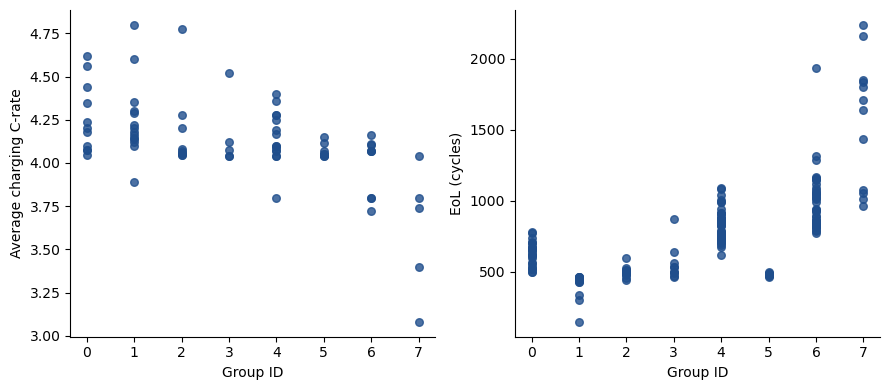

In [23]:
# plots
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for g in range(N_GROUPS):
    cmask = final_cellGrp == g
    pmask = best_polGrp == g

    axes[0].scatter(
        np.full(pmask.sum(), g),
        policy_avgCrate[pmask],
        color='#1f4e8c', s=30, alpha=0.8
    )

    axes[1].scatter(
        np.full(cmask.sum(), g),
        eol_cycles[cmask],
        color='#1f4e8c', s=30, alpha=0.8
    )

axes[0].set_xlabel('Group ID')
axes[0].set_ylabel('Average charging C-rate')
axes[1].set_xlabel('Group ID')
axes[1].set_ylabel('EoL (cycles)')

for ax in axes:
    ax.set_xticks(range(N_GROUPS))
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)

plt.tight_layout()
plt.savefig('fig4_group_crate_eol.png', dpi=150)
plt.show()

In [24]:
# run constrained K-means on avg C-rate of cells
X = avgCrates.reshape(-1, 1)   # reshape from 1D to 2D to make each element its own array (e.g. 3.6 becomes [3.6])
km = KMeansConstrained(n_clusters=8, size_min=10, size_max=100, random_state=42)
km.fit(X)

# extract cluster assignment for each cell
final_cellGrp_km = km.labels_

# relabel by descending C-rate
centers = km.cluster_centers_.flatten() # convert 2d array of means to 1d array of means (each element which was an array containing one value is now just a value)
sorted_order = np.argsort(centers)[::-1] # sort group avg c-rate by descending order
remap = {old: new for new, old in enumerate(sorted_order)} # dict mapping where new is index in sorted_order and old is the index from final_cellGrp_km
final_cellGrp_km = np.array([remap[l] for l in final_cellGrp_km]) # order cells based on descending order of groups

VPC = 38.973%

Group  cells  policies    avgC  meanEoL  stdEoL
--------------------------------------------------
    0      10          4    4.699       467      139
    1      10          4    4.480       620       78
    2      16          8    4.312       671      168
    3      30         13    4.192       723      169
    4      63         23    4.093       862      261
    5      20         15    4.047       599      298
    6      10          5    3.914      1040      390
    7      10          6    3.590      1428      501


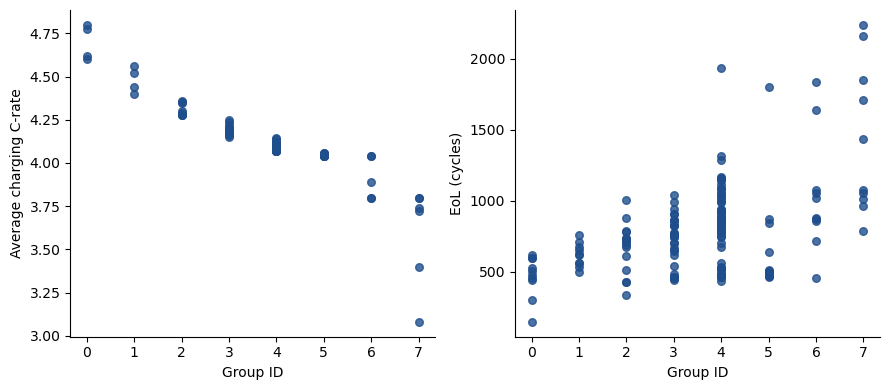

In [ ]:
# reconstruct policy-level group from cell-level km labels (needed for policy-level summaries)
best_polGrp_km = np.array([
    np.bincount(final_cellGrp_km[cellPolicyId == p], minlength=N_GROUPS).argmax() # count cells of policy p in each group, assign policy to the most common group
    for p in range(len(policy_list))
])

# compute VPC
vpc_km = computeVPC(final_cellGrp_km, eol_cycles)
print(f"VPC = {vpc_km*100:.3f}%\n")

# group summary table
nj_km      = np.array([(final_cellGrp_km == g).sum() for g in range(N_GROUPS)])
u_bar_j_km = np.array([eol_cycles[final_cellGrp_km == g].mean() for g in range(N_GROUPS)])

print(f"{'Group':>5} {'cells':>6} {'policies':>9} {'avgC':>7} "
      f"{'meanEoL':>8} {'stdEoL':>7}")
print("-" * 50)
for g in range(N_GROUPS):
    cmask = final_cellGrp_km == g
    pmask = best_polGrp_km == g
    print(f"  {g:>3}  {nj_km[g]:>6}  {pmask.sum():>9}  "
          f"{policy_avgCrate[pmask].mean():>7.3f}  "
          f"{u_bar_j_km[g]:>8.0f}  {eol_cycles[cmask].std():>7.0f}")
np.save('../data/best_polGrp_km.npy',    best_polGrp_km)        # VPC ~39%

# plots
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for g in range(N_GROUPS):
    cmask = final_cellGrp_km == g
    pmask = best_polGrp_km == g
    axes[0].scatter(np.full(pmask.sum(), g), policy_avgCrate[pmask],
                    color='#1f4e8c', s=30, alpha=0.8)
    axes[1].scatter(np.full(cmask.sum(), g), eol_cycles[cmask],
                    color='#1f4e8c', s=30, alpha=0.8)

axes[0].set_xlabel('Group ID'); axes[0].set_ylabel('Average charging C-rate')
axes[1].set_xlabel('Group ID'); axes[1].set_ylabel('EoL (cycles)')
for ax in axes:
    ax.set_xticks(range(N_GROUPS))
    for s in ['top', 'right']: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig('fig4_km_group_crate_eol.png', dpi=150)
plt.show()

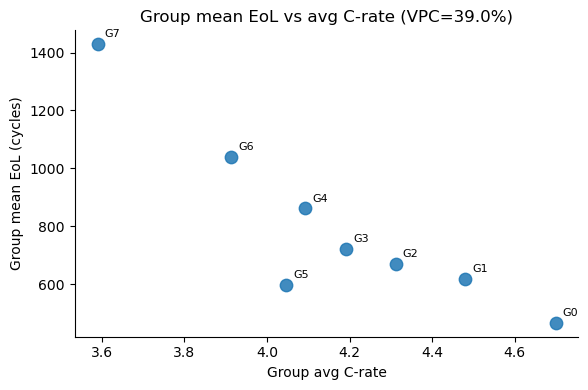

In [26]:
g_avgCrate_km = np.array([policy_avgCrate[best_polGrp_km == g].mean() for g in range(N_GROUPS)])
g_meanEoL_km  = np.array([eol_cycles[final_cellGrp_km == g].mean() for g in range(N_GROUPS)])

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(g_avgCrate_km, g_meanEoL_km, s=80, alpha=0.85)
for g in range(N_GROUPS):
    ax.annotate(f'G{g}', (g_avgCrate_km[g], g_meanEoL_km[g]), textcoords='offset points', xytext=(5, 5), fontsize=8)
ax.set_xlabel('Group avg C-rate')
ax.set_ylabel('Group mean EoL (cycles)')
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
plt.title(f'Group mean EoL vs avg C-rate (VPC={vpc_km*100:.1f}%)')
plt.tight_layout()
plt.show()